In [18]:
import kagglehub
import pandas as pd
import numpy as np
import os

# Download latest version
path = kagglehub.dataset_download("faviovaz/marketing-ab-testing")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'marketing-ab-testing' dataset.
Path to dataset files: /kaggle/input/marketing-ab-testing


In [19]:
csv_file = os.path.join(path, "marketing_AB.csv")
df = pd.read_csv(csv_file)
df.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


**Cleaning the data**

In [20]:
# Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (588101, 7)

Column names: ['unnamed:_0', 'user_id', 'test_group', 'converted', 'total_ads', 'most_ads_day', 'most_ads_hour']

First 5 rows:


,unnamed:_0,user_id,test_group,converted,total_ads,most_ads_day,most_ads_hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [21]:
df = df.drop(columns=['unnamed:_0'])
print("Clean columns:", df.columns.tolist())

Clean columns: ['user_id', 'test_group', 'converted', 'total_ads', 'most_ads_day', 'most_ads_hour']


In [22]:
print("=== Group Sizes ===")
print(df['test_group'].value_counts())

print("\n=== Conversion Rates ===")
print(df.groupby('test_group')['converted'].agg(['sum','count','mean'])
        .rename(columns={'sum':'conversions','count':'visitors','mean':'cvr'}))

print("\n=== Missing Values ===")
print(df.isnull().sum())

=== Group Sizes ===
test_group
ad     564577
psa     23524
Name: count, dtype: int64

=== Conversion Rates ===
            conversions  visitors       cvr
test_group                                 
ad                14423    564577  0.025547
psa                 420     23524  0.017854

=== Missing Values ===
user_id          0
test_group       0
converted        0
total_ads        0
most_ads_day     0
most_ads_hour    0
dtype: int64


**Data Analysis**

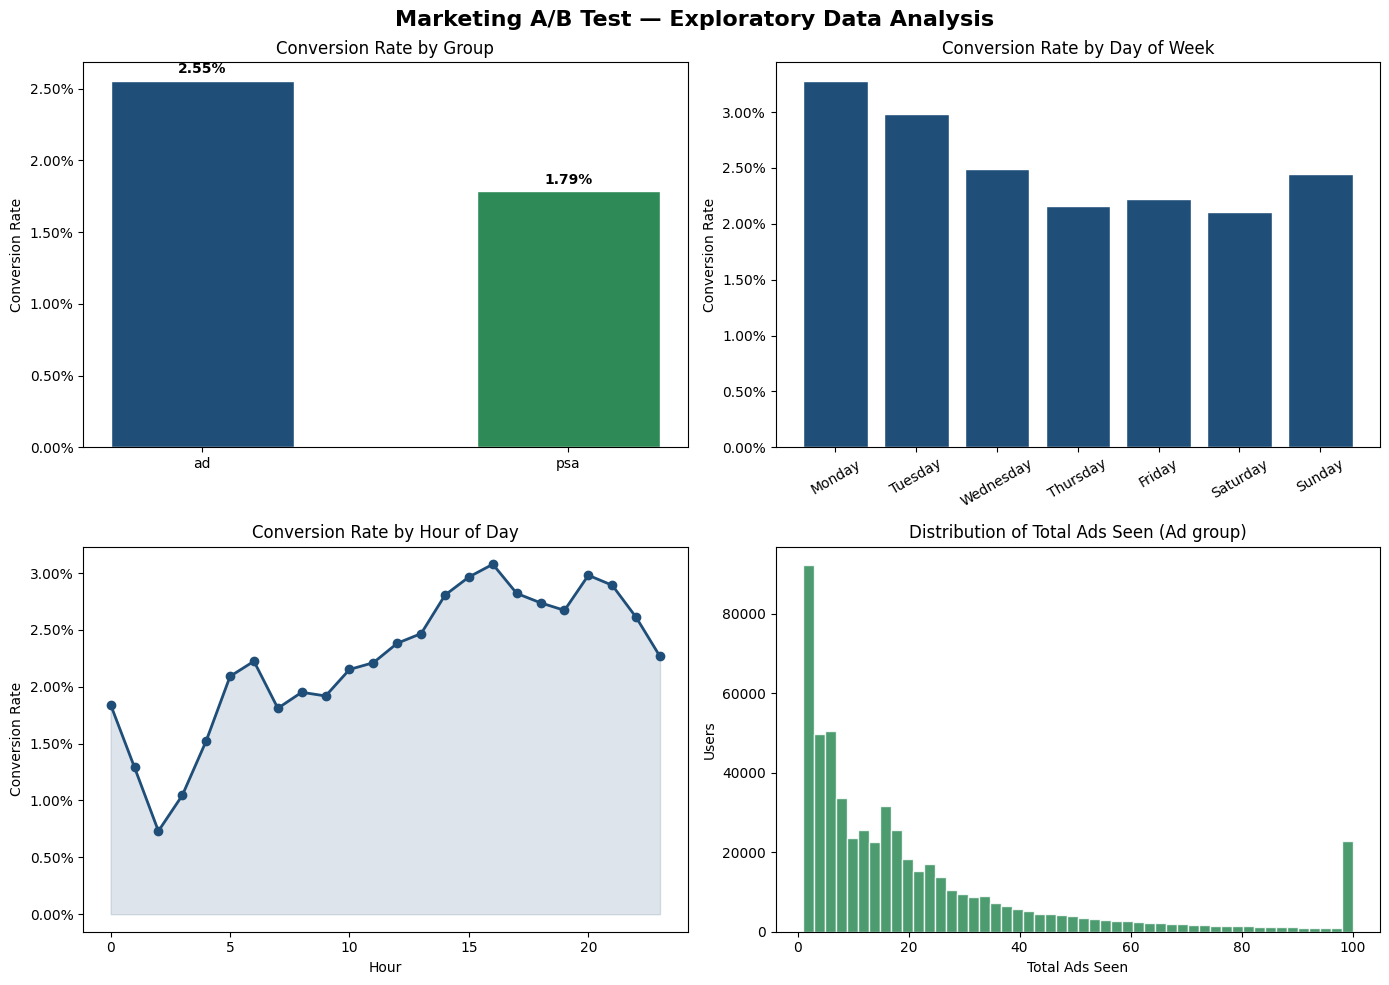

In [23]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Marketing A/B Test — Exploratory Data Analysis", fontsize=16, fontweight='bold')

BLUE  = "#1F4E79"
GREEN = "#2E8B57"

# 1. Conversion rate by group
grp = df.groupby('test_group')['converted'].mean()
bars = axes[0,0].bar(grp.index, grp.values, color=[BLUE, GREEN], edgecolor='white', width=0.5)
axes[0,0].set_title("Conversion Rate by Group")
axes[0,0].set_ylabel("Conversion Rate")
axes[0,0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
for bar, val in zip(bars, grp.values):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, val + 0.0005,
                   f"{val:.2%}", ha='center', fontweight='bold')

# 2. Conversion rate by day of week
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_cvr = df.groupby('most_ads_day')['converted'].mean().reindex(day_order)
axes[0,1].bar(day_cvr.index, day_cvr.values, color=BLUE, edgecolor='white')
axes[0,1].set_title("Conversion Rate by Day of Week")
axes[0,1].set_ylabel("Conversion Rate")
axes[0,1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0,1].tick_params(axis='x', rotation=30)

# 3. Conversion rate by hour
hour_cvr = df.groupby('most_ads_hour')['converted'].mean()
axes[1,0].plot(hour_cvr.index, hour_cvr.values, color=BLUE, marker='o', linewidth=2)
axes[1,0].fill_between(hour_cvr.index, hour_cvr.values, alpha=0.15, color=BLUE)
axes[1,0].set_title("Conversion Rate by Hour of Day")
axes[1,0].set_xlabel("Hour")
axes[1,0].set_ylabel("Conversion Rate")
axes[1,0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# 4. Distribution of total ads seen
ad_group = df[df['test_group'] == 'ad']['total_ads'].clip(upper=100)
axes[1,1].hist(ad_group, bins=50, color=GREEN, edgecolor='white', alpha=0.85)
axes[1,1].set_title("Distribution of Total Ads Seen (Ad group)")
axes[1,1].set_xlabel("Total Ads Seen")
axes[1,1].set_ylabel("Users")

plt.tight_layout()
plt.savefig("eda.png", dpi=150, bbox_inches='tight')
plt.show()

In [24]:
from scipy import stats

grp_stats = df.groupby('test_group')['converted'].agg(['sum','count'])
grp_stats.columns = ['conversions', 'visitors']
grp_stats['cvr'] = grp_stats['conversions'] / grp_stats['visitors']

n_a    = grp_stats.loc['psa',  'visitors']
conv_a = grp_stats.loc['psa',  'conversions']
n_b    = grp_stats.loc['ad',   'visitors']
conv_b = grp_stats.loc['ad',   'conversions']
p_a    = grp_stats.loc['psa',  'cvr']
p_b    = grp_stats.loc['ad',   'cvr']

print(grp_stats)
print(f"\nLift: {(p_b - p_a)/p_a * 100:+.2f}%")

            conversions  visitors       cvr
test_group                                 
ad                14423    564577  0.025547
psa                 420     23524  0.017854

Lift: +43.09%


In [25]:
ALPHA = 0.05

# Z-Test
p_pool = (conv_a + conv_b) / (n_a + n_b)
se     = np.sqrt(p_pool * (1 - p_pool) * (1/n_a + 1/n_b))
z_stat = (p_b - p_a) / se
p_val  = 2 * (1 - stats.norm.cdf(abs(z_stat)))

# Chi-Square
table      = np.array([[conv_a, n_a - conv_a],
                        [conv_b, n_b - conv_b]])
chi2, p_chi, dof, _ = stats.chi2_contingency(table, correction=False)

# Wilson Confidence Intervals
def wilson_ci(conv, n, alpha=0.05):
    p  = conv / n
    z  = stats.norm.ppf(1 - alpha/2)
    d  = 1 + z**2/n
    c  = (p + z**2/(2*n)) / d
    m  = (z * np.sqrt(p*(1-p)/n + z**2/(4*n**2))) / d
    return c - m, c + m

ci_a = wilson_ci(conv_a, n_a)
ci_b = wilson_ci(conv_b, n_b)

print("=" * 50)
print("       FREQUENTIST ANALYSIS")
print("=" * 50)
print(f"Z-Statistic      : {z_stat:.4f}")
print(f"p-value (z-test) : {p_val:.6f}")
print(f"Chi-Square       : {chi2:.4f}")
print(f"p-value (χ²)     : {p_chi:.6f}")
print(f"95% CI — Control : ({ci_a[0]:.4%}, {ci_a[1]:.4%})")
print(f"95% CI — Ad      : ({ci_b[0]:.4%}, {ci_b[1]:.4%})")
print(f"\nSignificant at α={ALPHA}: {'YES' if p_val < ALPHA else 'NO'}")

       FREQUENTIST ANALYSIS
Z-Statistic      : 7.3701
p-value (z-test) : 0.000000
Chi-Square       : 54.3181
p-value (χ²)     : 0.000000
95% CI — Control : (1.6239%, 1.9627%)
95% CI — Ad      : (2.5138%, 2.5961%)

Significant at α=0.05: YES


With a z-statistic of 7.37 and p-value of 1.7×10⁻¹³, we can reject the null hypothesis. The ad caused a 43% lift in conversion rate.

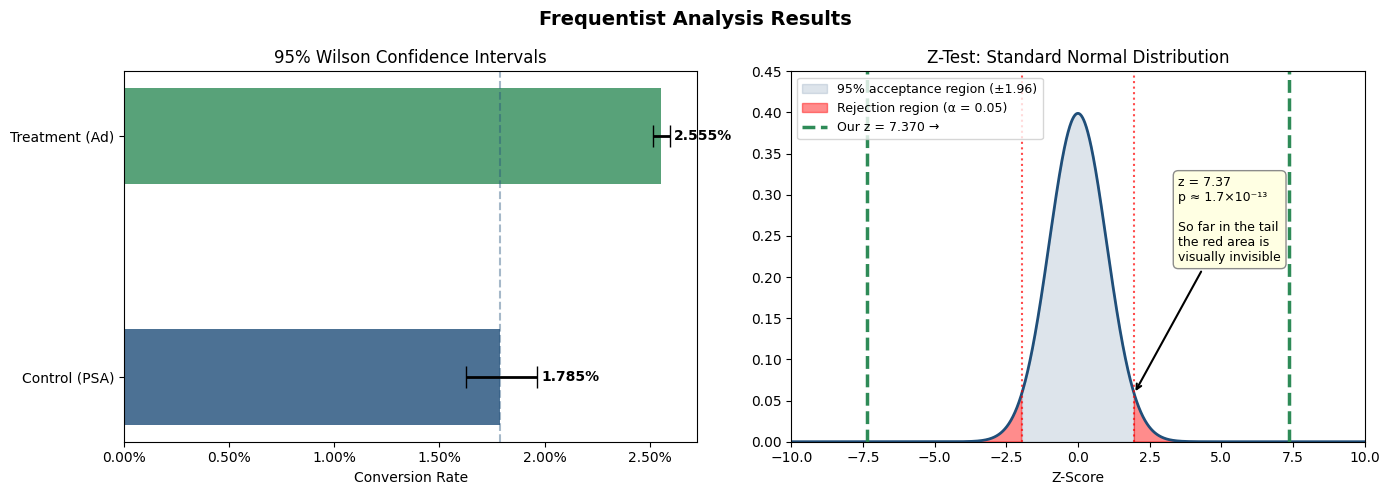

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CI plot
labels = ['Control (PSA)', 'Treatment (Ad)']
means  = [p_a, p_b]
errors = [(p_a - ci_a[0], ci_a[1] - p_a),
          (p_b - ci_b[0], ci_b[1] - p_b)]

for i, (lbl, mean, err, color) in enumerate(zip(labels, means, errors, [BLUE, GREEN])):
    axes[0].barh(i, mean, xerr=[[err[0]], [err[1]]],
                 color=color, alpha=0.8, capsize=8, height=0.4,
                 error_kw=dict(elinewidth=2, ecolor='black'))
    axes[0].text(mean + err[1] + 0.0002, i, f"{mean:.3%}", va='center', fontweight='bold')

axes[0].set_yticks([0, 1])
axes[0].set_yticklabels(labels)
axes[0].set_xlabel("Conversion Rate")
axes[0].set_title("95% Wilson Confidence Intervals")
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].axvline(p_a, linestyle='--', color=BLUE, alpha=0.4)

# Z-test plot (fixed for extreme z)
x_range = np.linspace(-10, 10, 2000)
y_norm  = stats.norm.pdf(x_range)

# Base curve
axes[1].plot(x_range, y_norm, color=BLUE, linewidth=2)

# Acceptance region (between ±1.96)
axes[1].fill_between(x_range, y_norm,
                      where=(x_range >= -1.96) & (x_range <= 1.96),
                      color=BLUE, alpha=0.15, label='95% acceptance region (±1.96)')

# Rejection tails (beyond ±1.96) — red and clearly visible
axes[1].fill_between(x_range, y_norm,
                      where=(x_range <= -1.96) | (x_range >= 1.96),
                      color='red', alpha=0.45, label='Rejection region (α = 0.05)')

# Vertical lines for ±1.96 critical values
axes[1].axvline( 1.96, color='red', linestyle=':', linewidth=1.5, alpha=0.7)
axes[1].axvline(-1.96, color='red', linestyle=':', linewidth=1.5, alpha=0.7)

# Our z-statistic — off the chart so we draw it at the edge with an arrow
axes[1].axvline(min(z_stat, 9.5), color=GREEN, linestyle='--', linewidth=2.5,
                label=f'Our z = {z_stat:.3f} →')
axes[1].axvline(max(-z_stat, -9.5), color=GREEN, linestyle='--', linewidth=2.5)

# Annotation box explaining the p-value
axes[1].annotate(
    f'z = {z_stat:.2f}\np ≈ 1.7×10⁻¹³\n\nSo far in the tail\nthe red area is\nvisually invisible',
    xy=(1.96, stats.norm.pdf(1.96)),
    xytext=(3.5, 0.22),
    arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
    fontsize=9,
    bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='gray', alpha=0.9)
)

axes[1].set_xlim(-10, 10)
axes[1].set_ylim(0, 0.45)
axes[1].set_title("Z-Test: Standard Normal Distribution")
axes[1].set_xlabel("Z-Score")
axes[1].legend(fontsize=9, loc='upper left')

plt.suptitle("Frequentist Analysis Results", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("frequentist.png", dpi=150, bbox_inches='tight')
plt.show()

Bayesian Analysis

In [27]:
np.random.seed(42)
SAMPLES = 200_000

# Posterior: Beta(1 + conversions, 1 + non-conversions)
alpha_a, beta_a = 1 + conv_a, 1 + (n_a - conv_a)
alpha_b, beta_b = 1 + conv_b, 1 + (n_b - conv_b)

samples_a = np.random.beta(alpha_a, beta_a, SAMPLES)
samples_b = np.random.beta(alpha_b, beta_b, SAMPLES)

prob_b_better = np.mean(samples_b > samples_a)
lift_dist     = (samples_b - samples_a) / samples_a * 100
expected_lift = np.mean(lift_dist)
lift_ci_low   = np.percentile(lift_dist, 2.5)
lift_ci_high  = np.percentile(lift_dist, 97.5)

print("=" * 50)
print("       BAYESIAN ANALYSIS")
print("=" * 50)
print(f"P(Ad beats PSA)    : {prob_b_better:.4%}")
print(f"Expected Lift      : {expected_lift:+.2f}%")
print(f"95% Credible Interval on Lift: ({lift_ci_low:.2f}%, {lift_ci_high:.2f}%)")

       BAYESIAN ANALYSIS
P(Ad beats PSA)    : 100.0000%
Expected Lift      : +43.11%
95% Credible Interval on Lift: (29.97%, 57.60%)


*Both methods converged, frequentist p-value of 1.7×10⁻¹³ and Bayesian P(B>A) of 100% from 200k Monte Carlo samples. Even the lower bound of the 95% credible interval shows a +30% lift, meaning the ad is better under virtually every plausible scenario.*

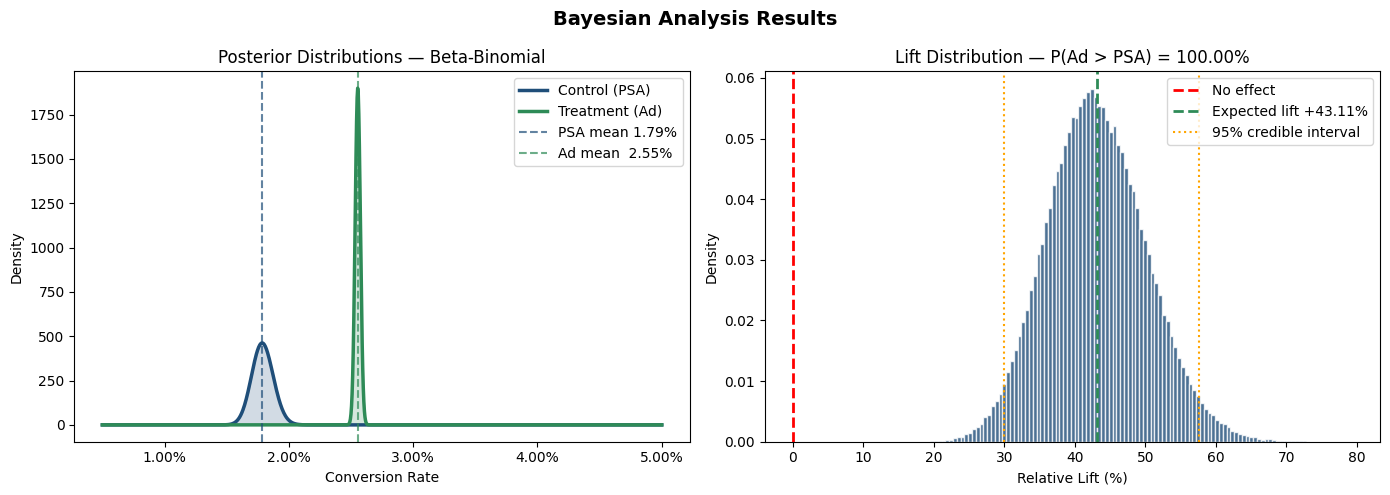

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Posterior distributions
x = np.linspace(0.005, 0.05, 1000)
axes[0].plot(x, stats.beta.pdf(x, alpha_a, beta_a),
             color=BLUE, linewidth=2.5, label='Control (PSA)')
axes[0].fill_between(x, stats.beta.pdf(x, alpha_a, beta_a),
                      alpha=0.2, color=BLUE)
axes[0].plot(x, stats.beta.pdf(x, alpha_b, beta_b),
             color=GREEN, linewidth=2.5, label='Treatment (Ad)')
axes[0].fill_between(x, stats.beta.pdf(x, alpha_b, beta_b),
                      alpha=0.2, color=GREEN)
axes[0].axvline(p_a, color=BLUE,  linestyle='--', alpha=0.7, label=f'PSA mean {p_a:.2%}')
axes[0].axvline(p_b, color=GREEN, linestyle='--', alpha=0.7, label=f'Ad mean  {p_b:.2%}')
axes[0].set_title("Posterior Distributions — Beta-Binomial")
axes[0].set_xlabel("Conversion Rate")
axes[0].set_ylabel("Density")
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].legend()

# Lift distribution
axes[1].hist(lift_dist, bins=120, color=BLUE, alpha=0.8, edgecolor='white', density=True)
axes[1].axvline(0,             color='red',   linestyle='--', linewidth=2, label='No effect')
axes[1].axvline(expected_lift, color=GREEN,   linestyle='--', linewidth=2,
                label=f'Expected lift {expected_lift:+.2f}%')
axes[1].axvline(lift_ci_low,   color='orange', linestyle=':', linewidth=1.5, label='95% credible interval')
axes[1].axvline(lift_ci_high,  color='orange', linestyle=':', linewidth=1.5)
axes[1].set_title(f"Lift Distribution — P(Ad > PSA) = {prob_b_better:.2%}")
axes[1].set_xlabel("Relative Lift (%)")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.suptitle("Bayesian Analysis Results", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("bayesian.png", dpi=150, bbox_inches='tight')
plt.show()

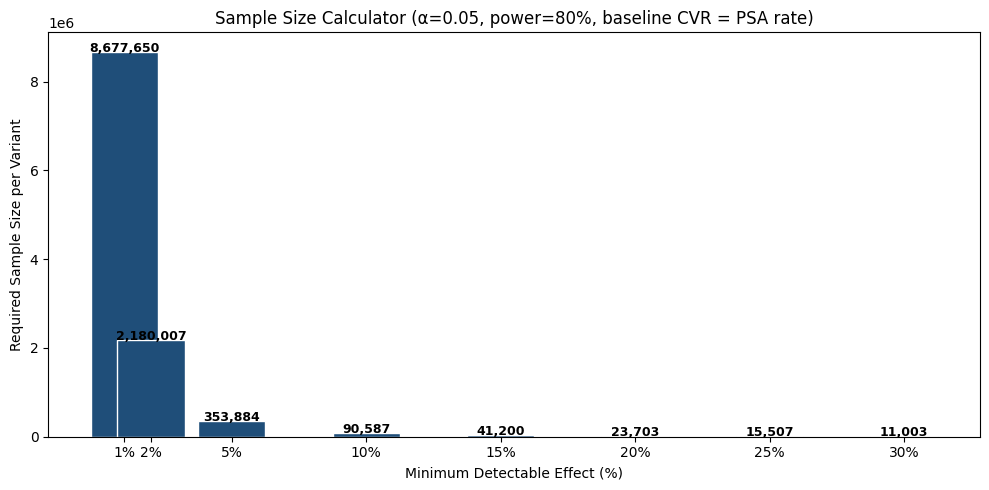


Sample Size Table:
 MDE (%)  Required n per Variant
       1                 8677650
       2                 2180007
       5                  353884
      10                   90587
      15                   41200
      20                   23703
      25                   15507
      30                   11003


In [29]:
def required_sample_size(p_base, mde_pct, alpha=0.05, power=0.80):
    p2    = p_base * (1 + mde_pct/100)
    p_avg = (p_base + p2) / 2
    za    = stats.norm.ppf(1 - alpha/2)
    zb    = stats.norm.ppf(power)
    n     = (za*np.sqrt(2*p_avg*(1-p_avg)) + zb*np.sqrt(p_base*(1-p_base)+p2*(1-p2)))**2 / (p_base-p2)**2
    return int(np.ceil(n))

mde_vals = [1, 2, 5, 10, 15, 20, 25, 30]
sizes    = [required_sample_size(p_a, m) for m in mde_vals]

plt.figure(figsize=(10, 5))
bars = plt.bar(mde_vals, sizes, color=BLUE, edgecolor='white', width=2.5)
for bar, size in zip(bars, sizes):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f"{size:,}", ha='center', fontsize=9, fontweight='bold')
plt.xlabel("Minimum Detectable Effect (%)")
plt.ylabel("Required Sample Size per Variant")
plt.title("Sample Size Calculator (α=0.05, power=80%, baseline CVR = PSA rate)")
plt.xticks(mde_vals, [f"{m}%" for m in mde_vals])
plt.tight_layout()
plt.savefig("sample_size.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nSample Size Table:")
ss_df = pd.DataFrame({'MDE (%)': mde_vals, 'Required n per Variant': sizes})
print(ss_df.to_string(index=False))

In [30]:
lift_obs = (p_b - p_a) / p_a * 100

print("=" * 55)
print("           FINAL EXPERIMENT SUMMARY")
print("=" * 55)
print(f"  Dataset          : Kaggle Marketing A/B (588k users)")
print(f"  Control (PSA)    : {n_a:,} users → {p_a:.3%} CVR")
print(f"  Treatment (Ad)   : {n_b:,} users → {p_b:.3%} CVR")
print(f"  Observed Lift    : {lift_obs:+.2f}%")
print("-" * 55)
print(f"  Z-Statistic      : {z_stat:.4f}")
print(f"  p-value          : {p_val:.2e}")
print(f"  Significant?     : {'YES' if p_val < ALPHA else 'NO'} (α = {ALPHA})")
print("-" * 55)
print(f"  P(Ad beats PSA)  : {prob_b_better:.2%}")
print(f"  Expected Lift    : {expected_lift:+.2f}%")
print(f"  95% Credible CI  : ({lift_ci_low:.2f}%, {lift_ci_high:.2f}%)")
print("=" * 55)

           FINAL EXPERIMENT SUMMARY
  Dataset          : Kaggle Marketing A/B (588k users)
  Control (PSA)    : 23,524 users → 1.785% CVR
  Treatment (Ad)   : 564,577 users → 2.555% CVR
  Observed Lift    : +43.09%
-------------------------------------------------------
  Z-Statistic      : 7.3701
  p-value          : 1.71e-13
  Significant?     : YES (α = 0.05)
-------------------------------------------------------
  P(Ad beats PSA)  : 100.00%
  Expected Lift    : +43.11%
  95% Credible CI  : (29.97%, 57.60%)
